
<style>
/* --- Notebook-wide typography and spacing --- */
.jp-RenderedHTMLCommon, .rendered_html, .bd-article, .nbinput, .nboutput {
  --toy-max-width: 980px;
}

.jp-RenderedHTMLCommon p, .rendered_html p, .bd-article p {
  line-height: 1.65;
  font-size: 1.02rem;
  margin-top: 0.35rem;
  margin-bottom: 0.9rem;
}

.jp-RenderedHTMLCommon h2, .rendered_html h2, .bd-article h2 {
  font-size: 2.05rem;
  line-height: 1.2;
  margin-top: 0.2rem;
  margin-bottom: 0.35rem;
  padding-bottom: 0.2rem;
  border-bottom: 1px solid rgba(128,128,128,0.18);
}

.jp-RenderedHTMLCommon h3, .rendered_html h3, .bd-article h3 {
  font-size: 1.45rem;
  line-height: 1.3;
  margin-top: 1.9rem;
  margin-bottom: 0.55rem;
}

.jp-RenderedHTMLCommon h4, .rendered_html h4, .bd-article h4 {
  font-size: 1.15rem;
  line-height: 1.35;
  margin-top: 1.35rem;
  margin-bottom: 0.45rem;
}

.jp-RenderedHTMLCommon ul, .rendered_html ul, .bd-article ul {
  margin-top: 0.35rem;
  margin-bottom: 0.95rem;
  padding-left: 1.4rem;
}

.jp-RenderedHTMLCommon li, .rendered_html li, .bd-article li {
  margin-bottom: 0.3rem;
  line-height: 1.6;
}

/* --- Code cells and outputs --- */
div.input_area, .jp-Cell-inputWrapper, .highlight, pre {
  border-radius: 12px;
}

.jp-CodeCell .jp-InputArea-editor, .input_area, div.highlight {
  font-size: 0.96rem;
}

.output_subarea, .jp-OutputArea-output {
  max-width: 100%;
}

.jp-OutputArea-output img, .output_subarea img {
  display: block;
  margin-left: auto;
  margin-right: auto;
  border-radius: 10px;
}

/* --- Visual polish --- */
hr {
  margin-top: 1.5rem !important;
  margin-bottom: 1.5rem !important;
}

blockquote {
  border-left: 4px solid rgba(59,130,246,0.55);
  margin: 1rem 0;
  padding: 0.25rem 0 0.25rem 1rem;
  background: rgba(59,130,246,0.06);
  border-radius: 0 10px 10px 0;
}

/* --- Keep content comfortably narrow in rendered contexts --- */
.jp-Notebook .jp-Cell, .notebook_app .cell, .bd-article {
  max-width: 980px;
}

/* --- Slightly more breathing room between cells --- */
.jp-Cell, .cell {
  margin-top: 0.45rem;
  margin-bottom: 0.45rem;
}
</style>


# Phase-type models for tract length distributions

In this tutorial, we illustrate how to use the functions in ``tracts`` to compute and depict tract length distributions under the different models of admixture introduced in the paper. These are, in increasing order of complexity:

* The Monoecious (M) model (only defined for autosomal admixture),
* The Dioecious-Coarse (DC) model,
* The Dioecious-Fine (DF) model,
* The hybrid-pedidree refinements of the DC (H-DC) and the DF (H-DF) models.

We start by importing the required python libraries:

In [1]:
from tracts.phase_type import PhTMonoecious, PhTDioecious
from tracts.phase_type import hybrid_pedigree as HP
from tracts.phase_type.plotting import plot_tractlength_density, plot_tractlength_histogram
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)

/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


The notebook will illustrate the implementation of the following diagram, for different admixture models and transmission scenarios:

![Phase-type model diagram](phasetype.png)

Throughout this notebook, we consider two source populations and a **continuous pulse** from the first to the second. This can be represented with the following migration matrix. The `whichpop` parameter sets the population of interest (0 or 1), that is, from which the tract length distribution is to be computed.

In [2]:
whichpop = 1
mig_matrix = np.array([[0, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0, 1]])

## 1. Choose autosomal or X chromosome admixture

In [3]:
X_chr = False # Set to True for admixture on the X chromosome
X_chr_male = False # Set to True if admixture is considered on the X chromosome of a male individual (only maternally inherited alleles).

In [4]:
which_L = 1.7928357829 # Second chromosome
#which_L = 1.96 # For the X chromosome
# Set a point grid on the finite chromosome
bins = np.linspace(0, which_L+0.1, num = 50)

## 2. Set sex-bias
The following parameters set the sex-bias for migration and recombination rates. The user can modify these parameters to observe how differences appear between all the considered models.

The migration sex-bias parameter `sex_bias` ranges from -1 (exclusively male migration) to 1 (exclusively female migration), with 0 corresponding to unbiased migration -- matching the sex-bias parametrization used throughout `tracts` (see the :ref:`user-guide`).

In [5]:
sex_bias = 0 # Sex-bias parameter, from -1 (exclusively male migration) to 1 (exclusively female migration). 0 corresponds to unbiased migration.
mig_f = mig_matrix + sex_bias*np.minimum(mig_matrix, 1-mig_matrix) # Female-specific migration matrix
mig_m = mig_matrix - sex_bias*np.minimum(mig_matrix, 1-mig_matrix) # Male-specific migration matrix
mig_m[-1,:] = mig_matrix[-1,:]
mig_f[-1,:] = mig_matrix[-1,:]

rho_f = 1 # Female-specific recombination rate
rho_m = 1 # Male-specific recombination rate

## 3. Compute model parameters and distributions

For the Monoecious (M), Dioecious Fine (DF), and Dioecious Coarse (DC) models, we first compute a `PhTMonoecious` or a `PhTDioecious` object, and then compute the corresponding phase-type density or histogram using the `tractlength_histogram_windowed` method. For the Pedigree-Dioecious models, densities and histograms are computed directly from the model parameters using the `hybrid_pedigree_distribution` function.

### 3.1 Monoecious model (only for autosomal admixture)
The Monoecious model is build using the `PhTMonoecious` class, and the tract length distribution is computed using the `tractlength_histogram_windowed` method. For comparison with the other settings, the Monoecious model is always computed using the mean migration matrix and the mean recombination rate.

In [6]:
PTmodel_mono = PhTMonoecious(migration_matrix=mig_matrix,
                            rho = 0.5*(rho_f+rho_m)) # PhTMonoecious object

# Compute tract length density (set freq = True for frequency scale)
newbins, density_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                                    bins=bins,
                                                                    L=which_L,
                                                                    density=True,
                                                                    freq=False)

# Compute tract length histogram
bins, hist_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False,
                                                            freq=False)

### 3.2 Dioecious Fine and Coarse models
The Dioecious Fine and Coarse models are build using the `PhTDioecious` class, and the tract length distribution is computed using the `tractlength_histogram_windowed` function. The Dioecious models are defined for both autosomal and X chromosome admixture, so we compute them using the sex-specific migration matrices and recombination rates.

In [7]:
# PhTDioecious objects (DF and DC models)
PTmodel_DF = PhTDioecious(migration_matrix_f=mig_f,
                        migration_matrix_m=mig_m,
                        rho_f=rho_f,
                        rho_m=rho_m,
                        sex_model='DF',
                        X_chromosome=X_chr,
                        X_chromosome_male=X_chr_male)

PTmodel_DC = PhTDioecious(migration_matrix_f=mig_f,
                        migration_matrix_m=mig_m,
                        rho_f=rho_f,
                        rho_m=rho_m,
                        sex_model='DC',
                        X_chromosome=X_chr,
                        X_chromosome_male=X_chr_male)

# Compute tract length densities (set freq = True for frequency scale)
newbins, density_df, E = PTmodel_DF.tractlength_histogram_windowed(population_number=whichpop,
                                                                bins=bins,
                                                                L=which_L,
                                                                density=True,
                                                                freq=False)

newbins, density_dc, E = PTmodel_DC.tractlength_histogram_windowed(population_number=whichpop,
                                                                bins=bins,
                                                                L=which_L,
                                                                density=True,
                                                                freq=False)

# Compute tract length histograms
bins, hist_df, E = PTmodel_DF.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False,
                                                            freq=False)

bins, hist_dc, E = PTmodel_DC.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False,
                                                            freq=False)

### 3.3 Hybrid-pedigree refinements

For the hybrid-pedigree refinements of the Dioecious models, we compute the tract length distributions directly using the `hybrid_pedigree_distribution` function. As the corresponding distribution is a Phase-Type mixture, the function interally defines one `PhTDioecious` object for each component, and then appropriately combine them using the mixture weights.

In [8]:
# Phase-Type mixture density for the H-DF model (set freq = True for frequency scale)
newbins, density_hp_df = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DF',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=X_chr,
                                                        X_chr_male=X_chr_male,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=False)

# Phase-Type mixture density for the H-DC model (set freq = True for frequency scale)
newbins, density_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DC',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=X_chr,
                                                        X_chr_male=X_chr_male,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=False)

# Phase-Type mixture histogram for the H-DF model
bins, hist_hp_df = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DF',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=X_chr,
                                                X_chr_male=X_chr_male,
                                                N_cores=5,
                                                density=False,freq=False)

# Phase-Type mixture histogram for the H-DC model
bins, hist_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DC',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=X_chr,
                                                X_chr_male=X_chr_male,
                                                N_cores=5,
                                                density=False,
                                                freq=False)

--------------------------------------------------------------------------------------------------------
Computing pedigrees probabilities for a Hybrid-Pedigree refinement of the DF model with T=2 generations.
--------------------------------------------------------------------------------------------------------



[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/home/jgonzale/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


...

[Parallel(n_jobs=5)]: Done   9 out of   9 | elapsed:    0.6s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.009244203567504883s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.011869192123413086s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done  11 out of 

--------------------------------------------
Done! Computing the final mixture density...
--------------------------------------------

--------------------------------------------------------------------------------------------------------
Computing pedigrees probabilities for a Hybrid-Pedigree refinement of the DC model with T=2 generations.
--------------------------------------------------------------------------------------------------------

--------------------------------------------------------------------
Done! Computing phase-type densities conditioned to each pedigree...
9 densities to compute using the DC model.
--------------------------------------------------------------------



[Parallel(n_jobs=5)]: Done   3 out of   9 | elapsed:    0.3s remaining:    0.6s
[Parallel(n_jobs=5)]: Done   4 out of   9 | elapsed:    0.4s remaining:    0.5s
[Parallel(n_jobs=5)]: Done   5 out of   9 | elapsed:    0.4s remaining:    0.3s
[Parallel(n_jobs=5)]: Done   6 out of   9 | elapsed:    0.4s remaining:    0.2s
[Parallel(n_jobs=5)]: Done   7 out of   9 | elapsed:    0.4s remaining:    0.1s


--------------------------------------------
Done! Computing the final mixture density...
--------------------------------------------



[Parallel(n_jobs=5)]: Done   9 out of   9 | elapsed:    0.5s finished


## 4. Plot tract length distributions

### 4.1 Plot densities

#### 4.1.1 Plot for autosomal admixture
The following code produces a figure depicting all the computed Phase-Type densities for autosomal admixture. Run if ``X_chr = False``.

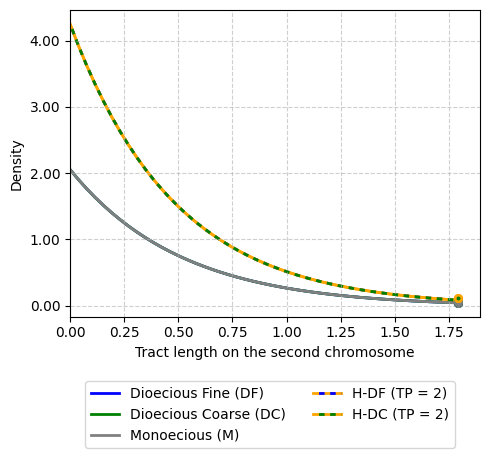

In [9]:
fig, ax = plot_tractlength_density(bins=newbins,
                                curves={'DF': density_df, 'DC': density_dc, 'M': density_m, 'H_DF': density_hp_df, 'H_DC': density_hp_dc},
                                L=which_L,
                                xlabel='Tract length on the second chromosome')
plt.show()

#### 4.1.2 Plot for X chromosome admixture
The following code produces a figure depicting all the computed Phase-Type densities for admixture on the X chromosome. Run if `X_chr = True`.

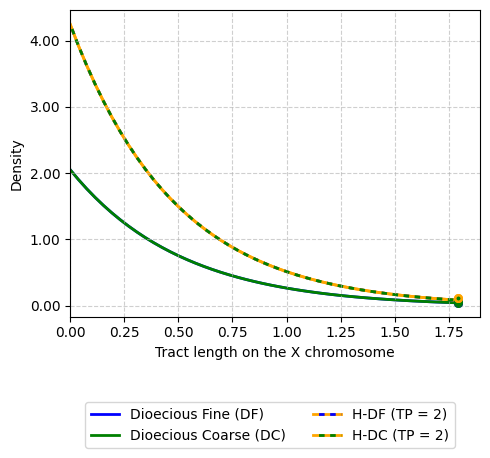

In [10]:
fig, ax = plot_tractlength_density(bins=newbins,
                                curves={'DF': density_df, 'DC': density_dc, 'H_DF': density_hp_df, 'H_DC': density_hp_dc},
                                L=which_L,
                                xlabel='Tract length on the X chromosome')
plt.show()

### 4.2 Plot histograms
#### 4.2.1 Plot for autosomal admixture
The following code produces a figure depicting all the computed Phase-Type histograms for autosomal admixture. Run if ``X_chr = False``.

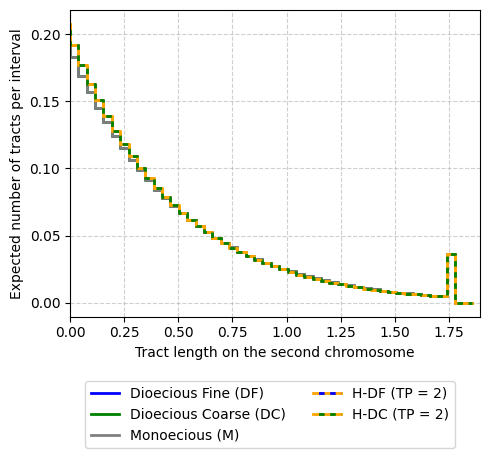

In [11]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'DF': hist_df, 'DC': hist_dc, 'M': hist_m, 'H_DF': hist_hp_df, 'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the second chromosome',
                                    L=which_L)
plt.show()

#### 4.2.2 Plot for X chromosome admixture
The following code produces a figure depicting all the computed Phase-Type histograms for admixture on the X chromosome. Run if ``X_chr = True``.

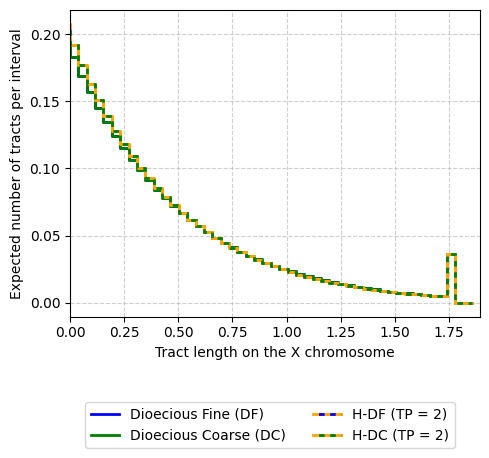

In [12]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'DF': hist_df, 'DC': hist_dc, 'H_DF': hist_hp_df, 'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the X chromosome',
                                    L=which_L)
plt.show()

## 5. Tract length distribution for a continuous pulse during 15 generations
We consider the following migration matrix, and let the user specify the sex-bias parameters as in the previous example. Once again, ``whichpop`` sets the population of interest (0 or 1).

In [13]:
whichpop = 1
mig_matrix = np.array([[0, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0.2, 0],[0, 1]])
print(np.shape(mig_matrix)[0]-1) # Number of generations

15


In [14]:
sex_bias = 0 # Sex-bias parameter, from -1 (exclusively male migration) to 1 (exclusively female migration). 0 corresponds to unbiased migration.
mig_f = mig_matrix + sex_bias*np.minimum(mig_matrix, 1-mig_matrix)
mig_m = mig_matrix - sex_bias*np.minimum(mig_matrix, 1-mig_matrix)
mig_m[-1,:] = mig_matrix[-1,:]
mig_f[-1,:] = mig_matrix[-1,:]

rho_f = 1 # Female-specific recombination rate
rho_m = 1 # Male-specific recombination rate

### 5.1 Monoecious model for autosomal admixture

In [15]:
PTmodel_mono = PhTMonoecious(migration_matrix=mig_matrix,
                            rho = 0.5*(rho_f+rho_m)) # PhTMonoecious object

# Phase-Type density (set freq = True for frequency scale)
newbins, density_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                                    bins=bins,
                                                                    L=which_L,
                                                                    density=True,
                                                                    freq=False)
# Phase-type histogram
bins, hist_m, E = PTmodel_mono.tractlength_histogram_windowed(population_number=whichpop,
                                                            bins=bins,
                                                            L=which_L,
                                                            density=False,
                                                            freq=False)

#### 5.1.1 Plot density

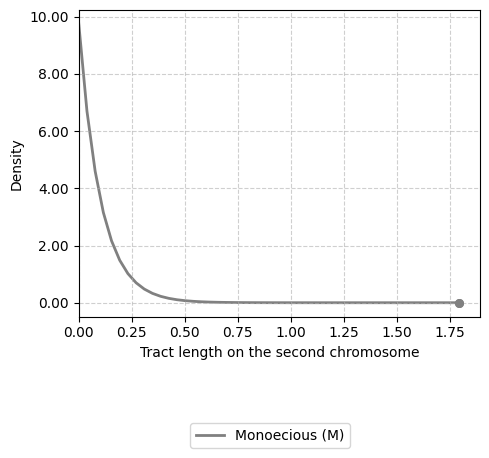

In [16]:
fig, ax = plot_tractlength_density(bins=newbins,
                                   curves={'M': density_m},
                                   L=which_L,
                                   xlabel='Tract length on the second chromosome')
plt.show()

#### 5.1.2 Plot histogram

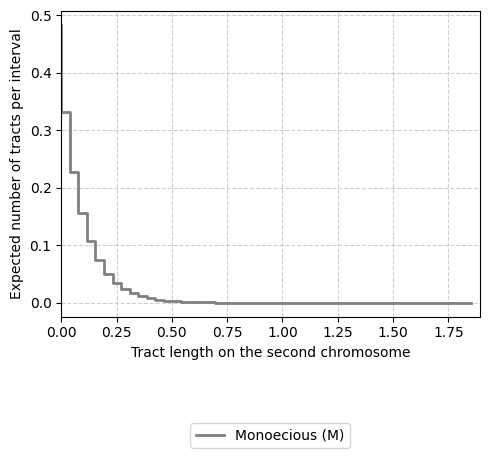

In [17]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'M': hist_m},
                                    xlabel='Tract length on the second chromosome',
                                    L=which_L)
plt.show()

### 5.2 Pedigree-DC model for X chromosome admixture

In [18]:
# The following lines can take a while to run, depending on the number of cores used and the size of the grid.

# Phase-Type mixture density for the H-DC model (set freq = True for frequency scale)
newbins, density_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                        mig_matrix_m=mig_m,
                                                        TP=2,
                                                        Dioecious_model='DC',
                                                        L=which_L,
                                                        bingrid=bins,
                                                        whichpop=whichpop,
                                                        rho_f=rho_f,
                                                        rho_m=rho_m,
                                                        X_chr=True,
                                                        X_chr_male=False,
                                                        N_cores=5,
                                                        density=True,
                                                        freq=True)

# Phase-Type histogram for the H-DC model
bins, hist_hp_dc = HP.hybrid_pedigree_distribution(mig_matrix_f=mig_f,
                                                mig_matrix_m=mig_m,
                                                TP=2,
                                                Dioecious_model='DC',
                                                L=which_L,
                                                bingrid=bins,
                                                whichpop=whichpop,
                                                rho_f=rho_f,
                                                rho_m=rho_m,
                                                X_chr=True,
                                                X_chr_male=False,
                                                N_cores=5,
                                                density=False,
                                                freq=False)

--------------------------------------------------------------------------------------------------------
Computing pedigrees probabilities for a Hybrid-Pedigree refinement of the DC model with T=2 generations.
--------------------------------------------------------------------------------------------------------

--------------------------------------------------------------------
Done! Computing phase-type densities conditioned to each pedigree...
9 densities to compute using the DC model.
--------------------------------------------------------------------



[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.008885383605957031s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.
[Parallel(n_jobs=5)]: Batch computation too fast (0.008762359619140625s.) Setting batch_size=2.
[Parallel(n_jobs=5)]: Done   4 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   6 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done   8 out of  11 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=5)]: Done  11 out of  11 | elapsed:    0.0s finished
[Parallel(n_jobs=5)]: Using backend Lo

[Parallel(n_jobs=5)]: Done   2 out of   9 | elapsed:    5.6s remaining:   19.8s


[Parallel(n_jobs=5)]: Done   3 out of   9 | elapsed:    9.2s remaining:   18.5s


[Parallel(n_jobs=5)]: Done   4 out of   9 | elapsed:   12.1s remaining:   15.2s
[Parallel(n_jobs=5)]: Done   5 out of   9 | elapsed:   12.1s remaining:    9.7s


...

[Parallel(n_jobs=5)]: Done   4 out of   9 | elapsed:   19.2s remaining:   24.1s
[Parallel(n_jobs=5)]: Done   5 out of   9 | elapsed:   19.2s remaining:   15.4s


[Parallel(n_jobs=5)]: Done   6 out of   9 | elapsed:   21.7s remaining:   10.8s


[Parallel(n_jobs=5)]: Done   7 out of   9 | elapsed:   31.4s remaining:    9.0s


--------------------------------------------
Done! Computing the final mixture density...
--------------------------------------------



[Parallel(n_jobs=5)]: Done   9 out of   9 | elapsed:   38.8s finished


#### 5.2.1 Plot density

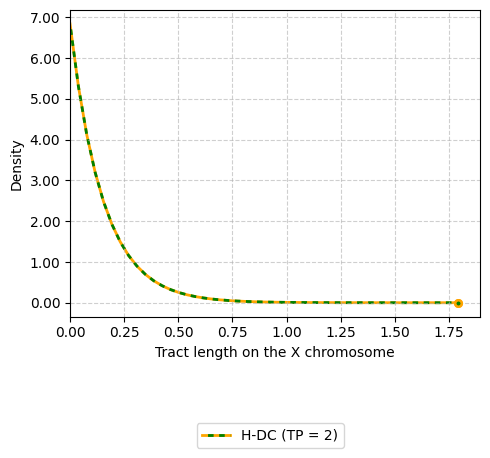

In [19]:
fig, ax = plot_tractlength_density(bins=newbins,
                                   curves={'H_DC': density_hp_dc},
                                   L=which_L,
                                   xlabel='Tract length on the X chromosome')
plt.show()

#### 5.2.2 Plot histogram

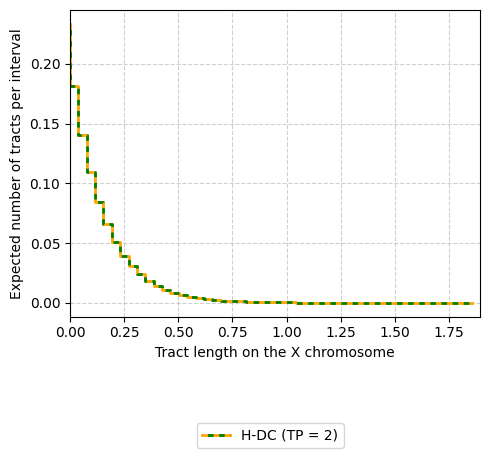

In [20]:
fig, ax = plot_tractlength_histogram(bins=bins,
                                    curves={'H_DC': hist_hp_dc},
                                    xlabel='Tract length on the X chromosome',
                                    L=which_L)
plt.show()